In [3]:
from pathlib import Path
import json
import pandas as pd

folder = Path(".").resolve().parent.parent / "experiments" / "cifar10" / "hyper"
names = {"SimpleNN", "LongLiquid", "BlockLiquid", "LongMoe", "BlockMoe"}

def get_mean_auc(folder: Path, name: str):
    n_lines = 0
    agg = 0

    if not (folder / f"{name}_accuracy.txt").is_file():
        return float("nan")

    with open(folder / f"{name}_accuracy.txt", "r") as f:
        for line in f:
            n_lines += 1
            agg += float(line)

    return agg / n_lines


def get_test_metrics(folder: Path, name: str) -> dict:


    with open(folder / f"{name}_test_metrics.txt", "r") as f:
        metrics = {}

        for line in f:
            key, value = line.split("=")
            metrics[key] = float(value)

    return metrics


def get_n_experts(folder: Path, name: str) -> int:

    if name == "SimpleNN":
        return 1

    with open(folder / "params.json", "r") as f:
        params = json.load(f)

    return params[name]["architecture"]["n_citizens"]

experiments = []

for ent in folder.iterdir():

    if not ent.is_dir():
        continue

    found = None
    for name in names:

        if not (ent / f"{name}.pt").is_file():
            continue

        assert found is None
        found = name

    assert found is not None

    metrics = get_test_metrics(ent, found)
    auc = get_mean_auc(ent, found)
    metrics["acc_auc"] = auc
    metrics["n_experts"] = get_n_experts(ent, found)

    experiments.append({
        "best_accuracy": metrics["best_accuracy"],
        "acc_auc": metrics["acc_auc"],
        "n_experts": metrics["n_experts"],
        "n_params": metrics["n_params"],
        "p_active": metrics["p_active_q_0.50"],
        "architecture": found
    })



df = pd.DataFrame(experiments)
df["active_n_params"] = df["n_params"] * df["p_active"]


<Axes: ylabel='Frequency'>

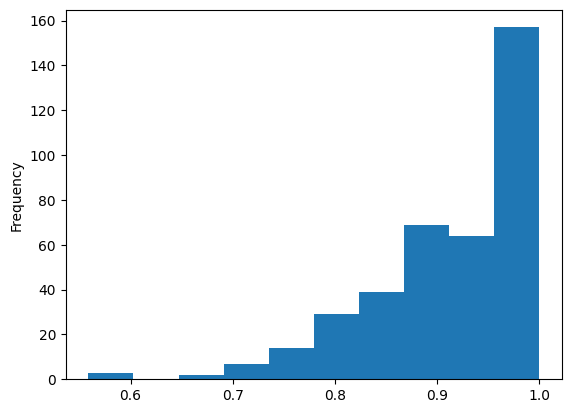

In [4]:
df[df["architecture"].str.contains("Liquid")]["p_active"].plot.hist()

<Axes: ylabel='Frequency'>

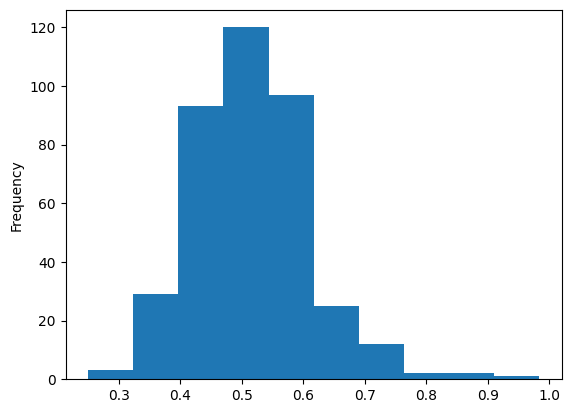

In [5]:
df[df["architecture"].str.contains("Moe")]["p_active"].plot.hist()

In [ ]:
df = df[df["acc_auc"].notnull()]

<Axes: ylabel='Frequency'>

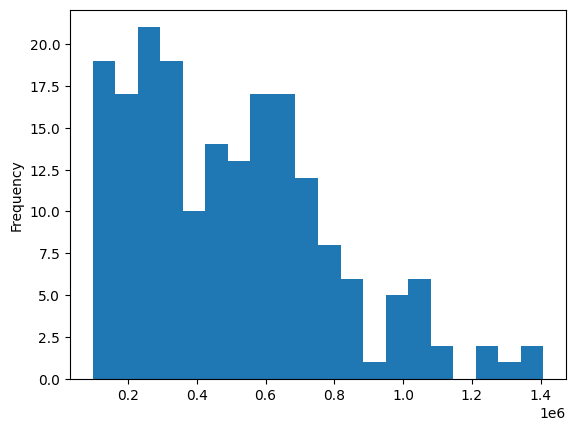

In [17]:
df[df["architecture"].str.contains("LongMoe")]["n_params"].plot.hist(bins=20)

In [11]:
df.groupby(["architecture", "n_experts"]).size()

architecture  n_experts
BlockLiquid   5            64
              10           64
              15           64
BlockMoe      5            64
              10           64
              15           64
LongLiquid    5            64
              10           64
              15           64
LongMoe       5            64
              10           64
              15           64
SimpleNN      1            64
dtype: int64

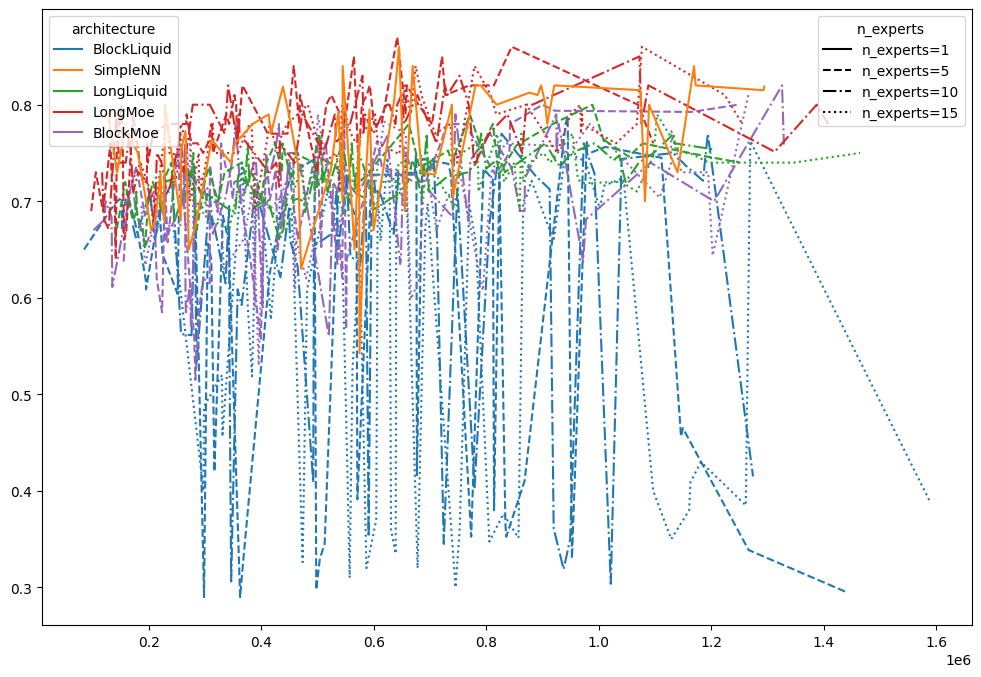

In [6]:
# params over top and AUC

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def plot_by_category(df, x_col, y_col):
    fig, ax = plt.subplots(figsize=(12, 8))

    architectures = df['architecture'].unique()
    n_experts_set = df['n_experts'].unique()

    colors = {arch: c for arch, c in zip(architectures, plt.cm.tab10.colors)}
    linestyles = {n: s for n, s in zip(sorted(n_experts_set), ['-', '--', '-.', ':'])}

    for (arch, n_exp), group in df.groupby(['architecture', 'n_experts']):
        group = group.sort_values(x_col)
        ax.plot(group[x_col], group[y_col], color=colors[arch], linestyle=linestyles[n_exp])

    color_lines = [mlines.Line2D([], [], color=colors[arch], linestyle='-', label=arch) for arch in architectures]
    style_lines = [mlines.Line2D([], [], color='black', linestyle=linestyles[n], label=f'n_experts={n}') for n in sorted(n_experts_set)]

    legend1 = ax.legend(handles=color_lines, title="architecture", loc='upper left')
    legend2 = ax.legend(handles=style_lines, title="n_experts", loc='upper right')
    ax.add_artist(legend1)

    plt.show()


plot_by_category(df, "n_params", "best_accuracy")

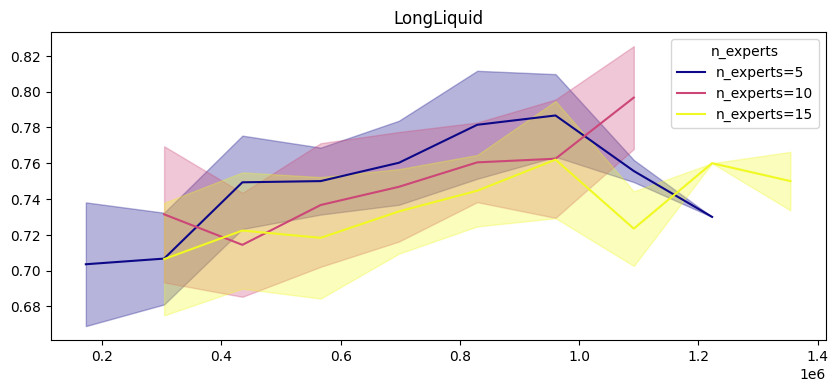

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_architecture(df, architecture, x_col, y_col, bins=10, ax=None):
    df_arch = df[df['architecture'] == architecture]
    n_experts_sorted = sorted(df_arch['n_experts'].unique())
    colors = plt.cm.plasma(np.linspace(0, 1, len(n_experts_sorted)))
    color_map = dict(zip(n_experts_sorted, colors))


    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    x_min, x_max = df_arch[x_col].min(), df_arch[x_col].max()
    bin_edges = np.linspace(x_min, x_max, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for n_exp in n_experts_sorted:
        sub = df_arch[df_arch['n_experts'] == n_exp].copy()
        sub['bin'] = pd.cut(sub[x_col], bins=bin_edges, include_lowest=True)
        grouped = sub.groupby('bin',  observed=False)[y_col]
        means = grouped.mean().values
        stds = grouped.std().fillna(0).values

        c = color_map[n_exp]
        ax.plot(bin_centers, means, color=c, label=f'n_experts={n_exp}')
        ax.fill_between(bin_centers, means - stds, means + stds, color=c, alpha=0.3)

    ax.set_title(architecture)
    ax.legend(title="n_experts")


plot_architecture(df, "LongLiquid", "n_params", "best_accuracy")


KeyError: 'Column not found: auc_acc'

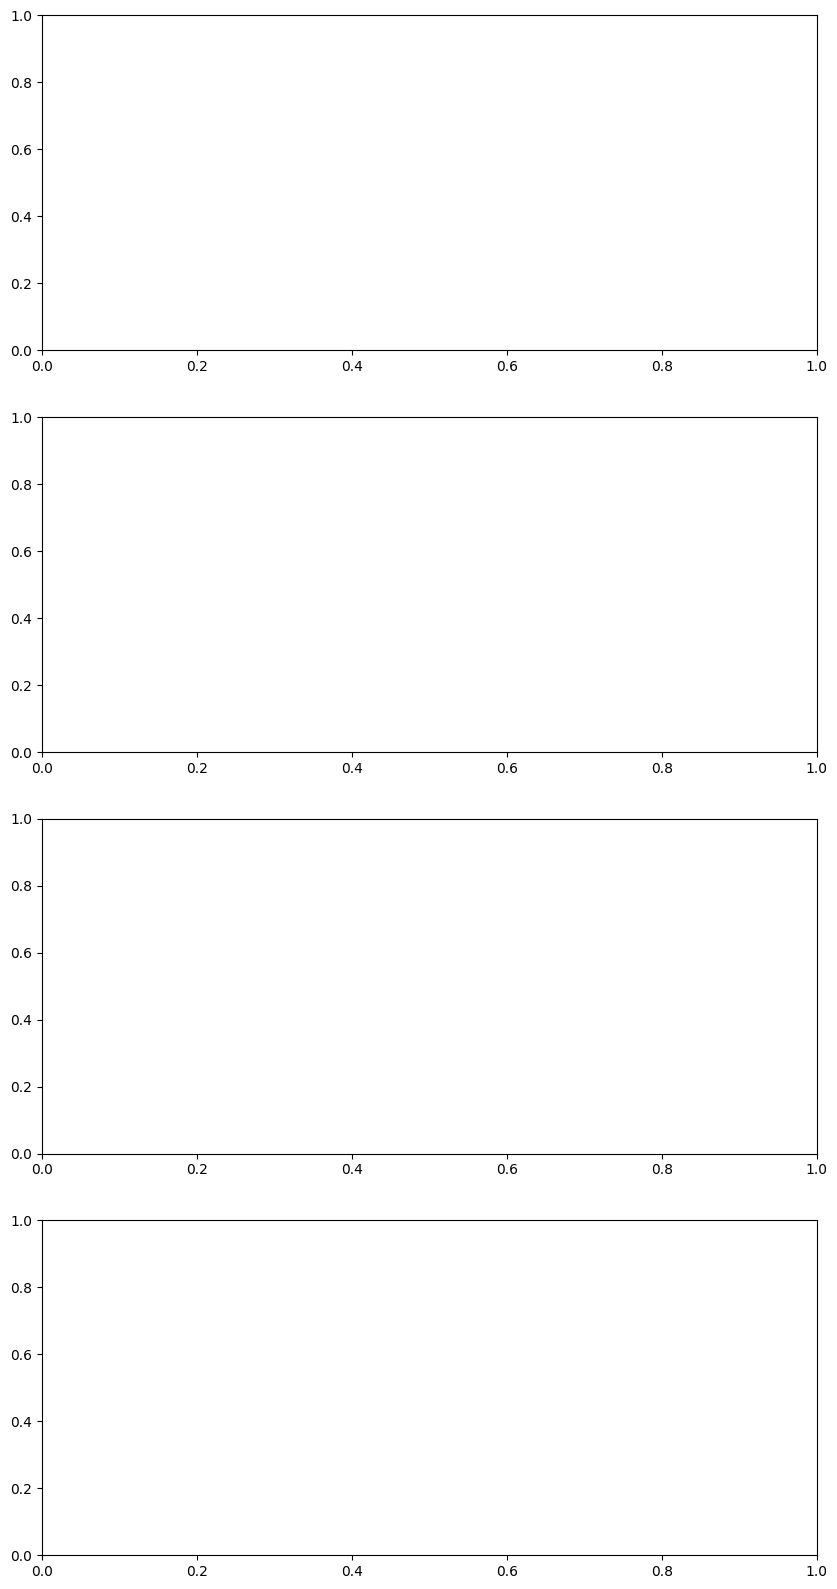

In [ ]:

fig, axs = plt.subplots(df["architecture"].unique().size, 1, figsize=(10, 20))

for ax, (arch, group) in zip(axs, df.groupby('architecture'), strict=True):

    plot_architecture(group, arch, "n_params", "auc_acc", ax=ax)

    ax.set_ylim([0, 1])

plt.show()